In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from useful_functions import *

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data      = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

ids = read_ids('filtered_ids.txt')

SPECTRA = Spectrum(spectra_data, color_data, cigale_data, fastspecfit, load_targetID=ids)


In [3]:
# SPECTRA = SPECTRA.SFG_filter(exclude=False)
SPECTRA = SPECTRA.subtype_filter(subtype='QSO', exclude=True)
# SPECTRA.shrink_dataset(10)

SPECTRA.stack_data()
SPECTRA.mask_bad()

In [4]:
FIT     = FitSpectrum()
SPECTRA = FIT.shift_to_rest_frame(SPECTRA)
print(SPECTRA.n_spectra)


4538


In [5]:
SPECTRA = FIT.label_emission_lines(SPECTRA, 3)
SPECTRA = FIT.significant_emission_filter(SPECTRA)
print(SPECTRA.n_spectra)

4538


In [166]:
idx = np.random.choice(SPECTRA.n_spectra, size=1, replace=False)[0]
id = SPECTRA.targetID[idx]
# id = 39627794258332730
# idx = SPECTRA.id2index(id)

39627775627237618
Saved ./images/39627775627237618_image.jpg


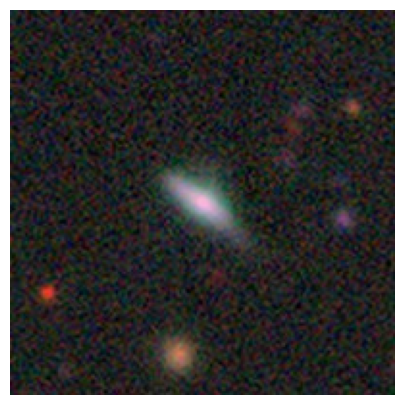

https://www.legacysurvey.org/viewer?ra=177.74183265987958&dec=-0.576726479133858&layer=ls-dr10-grz&zoom=14
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627775627237618


In [167]:
print(SPECTRA.targetID[idx])
print(image_link(SPECTRA.df['RA'].to_numpy()[idx], SPECTRA.df['DEC'].to_numpy()[idx], plot=True, save_image=True, fname=f"./images/{SPECTRA.targetID[idx]}_image.jpg"))
print(spectrum_link(SPECTRA.targetID[idx]))

# 1-Comp fit with dz

In [168]:
params_1comp_fixed, (combine_lam, combine_flux, combine_sigma), slice_indices, n_lines_fit = FIT.fit_multi_emission_vel(SPECTRA, id=id, two_component=False, w_dz=True)
print(f'dz: {params_1comp_fixed["dz"]}')

lams = np.split(combine_lam, slice_indices)

combine_model_lam = np.concatenate([
                model_vel(lams[i], gaussian_parms=params_1comp_fixed['gaussian_params'][i]) 
                for i in range(len(lams))
            ])
model_lam_1comp_fixed = combine_model_lam


combine_flux_1comp_fixed = combine_flux


chisq_1comp_fixed = np.sum(((combine_flux_1comp_fixed - model_lam_1comp_fixed)/combine_sigma)**2)
# print(f'Chi-sq dz 1 comp: {chisq_dz_1comp}')


dof_1comp_fixed = len(combine_lam) - (2+n_lines_fit)
# 2: dz, sigma_1

[-5.65599600e-06  8.35534195e+01  1.71922901e+01  1.12449569e+01
  1.10468148e+01  2.87245007e+00  3.36726227e+01  1.01952188e+01
  6.57811413e+00  4.68506281e+00]
dz: -5.655995995022425e-06


# 1-Comp without dz

In [169]:
params_1comp_free, (combine_lam, combine_flux, combine_sigma), slice_indices, n_lines_fit = FIT.fit_multi_emission_vel(SPECTRA, id=id, two_component=False, w_dz=False)

lams = np.split(combine_lam, slice_indices)

combine_model_lam = np.concatenate([
                model_vel(lams[i], gaussian_parms=params_1comp_free['gaussian_params'][i]) 
                for i in range(len(lams))
            ])
model_lam_1comp_free = combine_model_lam

combine_flux_1comp_free = combine_flux

chisq_1comp_free = np.sum(((combine_flux_1comp_free - model_lam_1comp_free)/combine_sigma)**2)
# print(f'Chi-sq dz 1 comp: {chisq_dz_1comp}')


dof_1comp_free = len(combine_lam) - (1+n_lines_fit)
# 1: sigma_1

[83.49930407 17.23947521 11.24950219 11.03797856  2.87743928 33.67262268
 10.18197233  6.60465223  4.69073638]


# 2-Comp fit with dz

In [170]:

params_2comp_fixed, (combine_lam, combine_flux, combine_sigma), slice_indices, n_lines_fit = FIT.fit_multi_emission_vel(SPECTRA, id=id, two_component=True, w_dz=True)
print(f'dz: {params_2comp_fixed["dz"]}')
print(f'dv_r: {params_2comp_fixed["dv"][0]}, dv_l: {params_2comp_fixed["dv"][1]}')

combine_flux_2comp_fixed = combine_flux

lams = np.split(combine_lam, slice_indices)

combine_model_lam = np.concatenate([
                model_vel(lams[i], gaussian_parms=params_2comp_fixed['gaussian_params'][i]) 
                for i in range(len(lams))
            ])
model_lam_2comp_fixed = combine_model_lam

left_comp_dz_fixed = np.concatenate([
    model_vel(lams[i], gaussian_parms=params_2comp_fixed['left_comp'][i]) for i in range(len(lams))
])
right_comp_dz_fixed = np.concatenate([
    model_vel(lams[i], gaussian_parms=params_2comp_fixed['right_comp'][i]) for i in range(len(lams))
])

chisq_2comp_fixed = np.sum(((combine_flux_2comp_fixed - model_lam_2comp_fixed)/combine_sigma)**2)
# print(f'Chi-sq dz fixed: {chisq_dz_fixed}')


dof_2comp_fixed = len(combine_lam) - (5+n_lines_fit*2)
# 5: dz, sigma_1, sigma_2, dz_r, dz_l

[-2.27875185e-05  5.74686892e+01  5.53099921e+01  4.88538418e+01
 -6.08585790e+01  1.53046160e+01  9.04277777e+00  8.97729876e+00
  2.84063964e+00  2.93479612e+01  8.58206463e+00  5.52838965e+00
  3.59810909e+00  1.02675237e+01  7.29140883e+00  7.09107133e+00
  1.27583170e+00  2.09253287e+01  6.14479641e+00  3.97317334e+00
  3.24073484e+00]
dz: -2.2787518501433284e-05
dv_r: 48.85384183133011, dv_l: -60.85857895474643


# 2-Comp fit without dz

In [171]:
params_2comp_free, (combine_lam, combine_flux, combine_sigma), slice_indices, n_lines_fit = FIT.fit_multi_emission_vel(SPECTRA, id=id, two_component=True, w_dz=False)
print(f'dz: {params_2comp_free["dz"]}')

combine_flux_2comp_free = combine_flux

lams = np.split(combine_lam, slice_indices)

combine_model_lam = np.concatenate([
    model_vel(lams[i], gaussian_parms=params_2comp_free['gaussian_params'][i]) for i in range(len(lams))
])
model_lam_2comp_free = combine_model_lam

left_comp_dz_free = np.concatenate([
    model_vel(lams[i], gaussian_parms=params_2comp_free['left_comp'][i]) for i in range(len(lams))
])
right_comp_dz_free = np.concatenate([
    model_vel(lams[i], gaussian_parms=params_2comp_free['right_comp'][i]) for i in range(len(lams))
])
model_lam_2comp_free = left_comp_dz_free + right_comp_dz_free

chisq_2comp_free = np.sum(((combine_flux_2comp_free - model_lam_2comp_free)/combine_sigma)**2)
# print(f'Chi-sq dz free: {chisq_dz_free}')


# left_area = np.sum(left_comp_dz_free)
# right_area = np.sum(right_comp_dz_free)
# dv_r, dv_l = params_2comp_free['dv']
# dz_centroid = (dv_r*left_area + dv_l*right_area)/(left_area+right_area)
# print(f'dz_centroid: {dz_centroid}')

dof_2comp_free = len(combine_lam) - (4+n_lines_fit*2)
# 4: sigma_1, sigma_2, dz_r, dz_l


[ 57.46367825  55.3132253   42.03004811 -67.67733891  15.30356811
   9.04183155   8.97639989   2.84052937  29.345207     8.58124487
   5.52790163   3.5976984   10.26881783   7.29236749   7.092
   1.27605917  20.92855422   6.14572152   3.97372431   3.24110586]
dz: 0


In [172]:
F_stat = ((chisq_1comp_fixed - chisq_2comp_fixed) / (dof_1comp_fixed - dof_2comp_fixed)) / (chisq_2comp_fixed / dof_2comp_fixed)
p_value = 1 - f.cdf(F_stat, dof_1comp_fixed - dof_2comp_fixed, dof_2comp_fixed)
print(f'Fixed p_value: {p_value}')


F_stat = ((chisq_1comp_free - chisq_2comp_free) / (dof_1comp_free - dof_2comp_free)) / (chisq_2comp_free / dof_2comp_free)
p_value = 1 - f.cdf(F_stat, dof_1comp_free - dof_2comp_free, dof_2comp_free)
print(f'Free p_value: {p_value}')



# F_stat = ((chisq_2comp_free - chisq_2comp_fixed) / (dof_1comp_free - dof_2comp_fixed)) / (chisq_2comp_fixed / dof_2comp_fixed)
# p_value = 1 - f.cdf(F_stat, dof_1comp_free - dof_2comp_fixed, dof_2comp_fixed)
# print(f'2comp vs p_value (if < 0.05, w/ dz): {p_value}')

Fixed p_value: 1.7148801751742937e-05
Free p_value: 1.027772719763842e-05


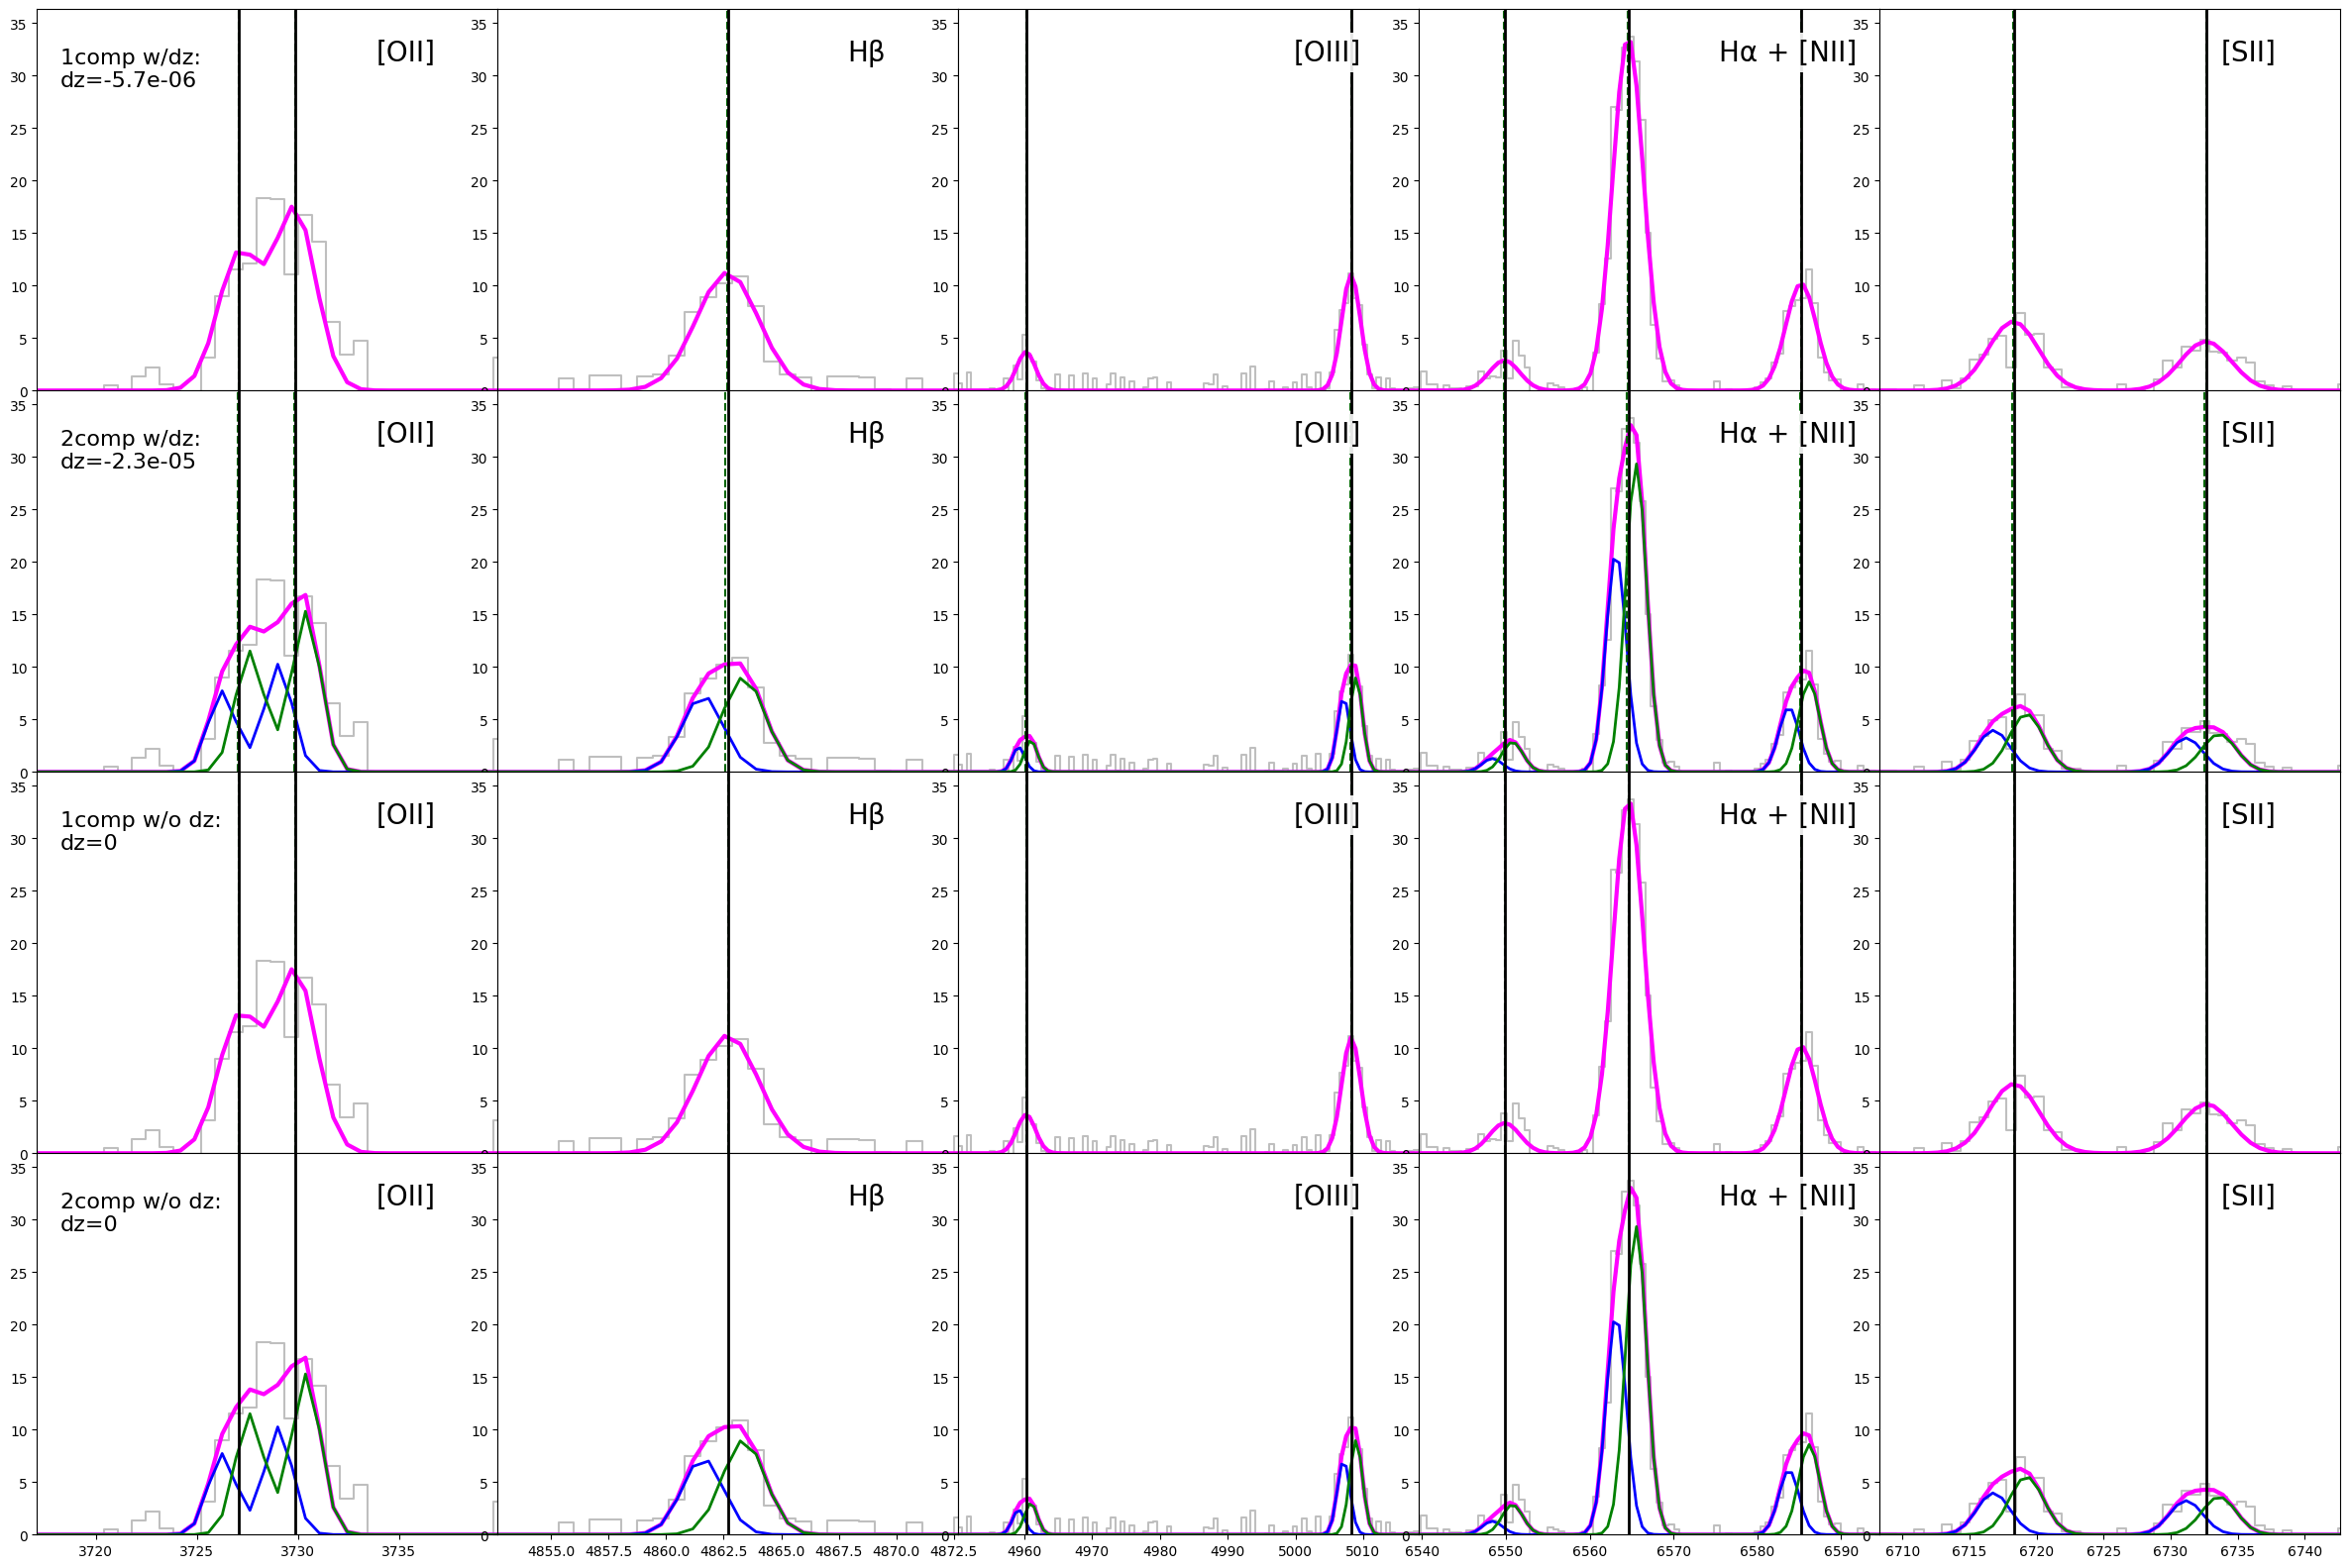

In [173]:

fig, axes = plt.subplots(4, 5, figsize=(30, 20))
plt.subplots_adjust(hspace=0.0, wspace=0.00)


# 1 comp fixed
ax = axes[0, :]
ax[0].text(0.05, 0.9, f'1comp w/dz: \ndz={params_1comp_fixed["dz"]:.1e}', transform=ax[0].transAxes, fontsize=16, verticalalignment='top')
for i in range(5):
    ax[i].step(combine_lam, combine_flux_1comp_fixed, label='Observed', where='mid', color='gray', alpha=0.5)
    ax[i].plot(combine_lam, model_lam_1comp_fixed, label='Fitted model_vel', color='magenta', linewidth=3)
    for l0 in [*lines_vac['OII'], *lines_vac['OIII'], *lines_vac['Hbeta'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0*(1+params_1comp_fixed['dz']), color='darkgreen', linestyle='--', alpha=1, linewidth=1.5)
        ax[i].axvline(l0, color='k', linestyle='-', alpha=1, linewidth=2)

# 2 comp fixed
ax = axes[1, :]
ax[0].text(0.05, 0.9, f'2comp w/dz: \ndz={params_2comp_fixed["dz"]:.1e}', transform=ax[0].transAxes, fontsize=16, verticalalignment='top')
for i in range(5):
    ax[i].step(combine_lam, combine_flux_2comp_fixed, label='Observed', where='mid', color='gray', alpha=0.5)
    ax[i].plot(combine_lam, model_lam_2comp_fixed, label='Fitted model_vel', color='magenta', linewidth=3)
    ax[i].plot(combine_lam, left_comp_dz_fixed, label='Left Component', color='blue', linestyle='-', linewidth=2)
    ax[i].plot(combine_lam, right_comp_dz_fixed, label='Right Component', color='green', linestyle='-', linewidth=2)
    for l0 in [*lines_vac['OII'], *lines_vac['OIII'], *lines_vac['Hbeta'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0*(1+params_2comp_fixed['dz']), color='darkgreen', linestyle='--', alpha=1, linewidth=1.5)
        ax[i].axvline(l0, color='k', linestyle='-', alpha=1, linewidth=2)


# 1 comp free
ax = axes[2, :]
ax[0].text(0.05, 0.9, f'1comp w/o dz: \ndz=0', transform=ax[0].transAxes, fontsize=16, verticalalignment='top')
for i in range(5):
    ax[i].step(combine_lam, combine_flux_1comp_free, label='Observed', where='mid', color='gray', alpha=0.5)
    ax[i].plot(combine_lam, model_lam_1comp_free, label='Fitted model_vel', color='magenta', linewidth=3)
    for l0 in [*lines_vac['OII'], *lines_vac['OIII'], *lines_vac['Hbeta'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0, color='darkgreen', linestyle='--', alpha=1, linewidth=1.5)
        ax[i].axvline(l0, color='k', linestyle='-', alpha=1, linewidth=2)


# 2 comp free
ax = axes[3, :]
ax[0].text(0.05, 0.9, f'2comp w/o dz: \ndz=0', transform=ax[0].transAxes, fontsize=16, verticalalignment='top')
for i in range(5):
    ax[i].step(combine_lam, combine_flux_2comp_free, label='Observed', where='mid', color='gray', alpha=0.5)
    ax[i].plot(combine_lam, model_lam_2comp_free, label='Fitted model_vel', color='magenta', linewidth=3)
    ax[i].plot(combine_lam, left_comp_dz_free, label='Left Component', color='blue', linestyle='-', linewidth=2)
    ax[i].plot(combine_lam, right_comp_dz_free, label='Right Component', color='green', linestyle='-', linewidth=2)
    for l0 in [*lines_vac['OII'], *lines_vac['OIII'], *lines_vac['Hbeta'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0*(1+params_2comp_free['dv'][0]), color='darkgreen', linestyle=':', alpha=.5, linewidth=1.5)
        ax[i].axvline(l0*(1+params_2comp_free['dv'][1]), color='darkblue', linestyle=':', alpha=.5, linewidth=1.5)
        # ax[i].axvline(l0*(1+dz_centroid), color='gray', linestyle='--', alpha=1, linewidth=1.5)
        ax[i].axvline(l0, color='k', linestyle='-', alpha=1, linewidth=2)

for i in range(4):
    ax = axes[i, :]
    ax[0].text(0.80, 0.85, '[OII]', transform=ax[0].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[0].set_xlim([OII_rest[0]-10, OII_rest[1]+10])  
    # ax[0].set_ylim(bottom=-0., top=np.max(combine_flux_2comp_free[(combine_lam>=OII_rest[0]-10) & (combine_lam<=OII_rest[1]+10)])*1.2)
    ax[0].set_ylim(bottom=-0.)

    ax[1].text(0.80, 0.85, 'Hβ', transform=ax[1].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[1].set_xlim([Hbeta_rest[0]-10, Hbeta_rest[0]+10])
    # ax[1].set_ylim(bottom=-0., top=np.max(combine_flux_2comp_free[(combine_lam>=Hbeta_rest[0]-10) & (combine_lam<=Hbeta_rest[0]+10)])*1.2)
    ax[1].set_ylim(bottom=-0.)
    
    ax[2].text(0.80, 0.85, '[OIII]', transform=ax[2].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[2].set_xlim([OIII_rest[0]-10, OIII_rest[1]+10])
    # ax[2].set_ylim(bottom=-0., top=np.max(combine_flux_2comp_free[(combine_lam>=OIII_rest[0]-10) & (combine_lam<=OIII_rest[1]+10)])*1.2)
    ax[2].set_ylim(bottom=-0.)
    
    ax[3].text(0.80, 0.85, 'Hα + [NII]', transform=ax[3].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[3].set_xlim([Halpha_rest[0]-25, Halpha_rest[0]+30])
    # ax[3].set_ylim(bottom=-0, top=np.max(combine_flux_2comp_free[(combine_lam>=Halpha_rest[0]-25) & (combine_lam<=Halpha_rest[0]+30)])*1.2)
    ax[3].set_ylim(bottom=-0)
    
    ax[4].text(0.80, 0.85, '[SII]', transform=ax[4].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[4].set_xlim([SII_rest[0]-10, SII_rest[1]+10])
    # ax[4].set_ylim(bottom=-0., top=np.max(combine_flux_2comp_free[(combine_lam>=SII_rest[0]-10) & (combine_lam<=SII_rest[1]+10)])*1.2)
    ax[4].set_ylim(bottom=-0.)
    
# plt.savefig(f'./figures/Dec10/{SPECTRA.targetID[idx]}_fit_comparison.png', dpi=300)
plt.show()

In [174]:
# import numpy as np
# from joblib import Parallel, delayed
# import os
# from tqdm import tqdm

# def fit_spectrum_worker(target_id):
#     """A wrapper function for the fitting process to be used by the executor."""
#     return FIT.fit_z(SPECTRA, id=target_id)

# n_jobs = 10

# results = Parallel(n_jobs=n_jobs)(delayed(fit_spectrum_worker)(i) for i in tqdm(SPECTRA.targetID))


In [175]:
# failed = []
# prefer_1comp = []
# prefer_2comp_wdz = []
# prefer_2comp_free = []

# for i, params in enumerate(results):
#     if isinstance(params, str):
#         failed.append(SPECTRA.targetID[i])
#     else:
#         if not isinstance(params['sigma'], tuple): # one comp
#             prefer_1comp.append(SPECTRA.targetID[i])
#         else:
#             if params['dz_centroid'] is None:
#                 prefer_2comp_wdz.append(SPECTRA.targetID[i])
#             else:
#                 prefer_2comp_free.append(SPECTRA.targetID[i])


In [176]:
# print(len(failed), len(prefer_1comp), len(prefer_2comp_wdz), len(prefer_2comp_free))

In [177]:
# from matplotlib.lines import Line2D

# for id in failed:
#     z_pipe = SPECTRA.z[SPECTRA.id2index(id)]
#     plt.scatter(z_pipe, 1e-10, color='gray', alpha=0.3)


# for id in prefer_1comp:
#     z_pipe = SPECTRA.z[SPECTRA.id2index(id)]
#     dz = results[SPECTRA.id2index(id)]['dz']
#     plt.scatter(z_pipe, dz, color='b', alpha=0.3)

# for id in prefer_2comp_wdz:
#     z_pipe = SPECTRA.z[SPECTRA.id2index(id)]
#     dz = results[SPECTRA.id2index(id)]['dz']
#     plt.scatter(z_pipe, dz, color='orange', alpha=0.3)

# for id in prefer_2comp_free:
#     z_pipe = SPECTRA.z[SPECTRA.id2index(id)]
#     dz_centroid = results[SPECTRA.id2index(id)]['dz_centroid']
#     plt.scatter(z_pipe, dz_centroid, color='r', alpha=0.3)


# plt.axhline(5e-5, color='k', linestyle='--', alpha=0.7)

# # Create custom legend handles
# legend_elements = [Line2D([0], [0], marker='o', color='w', label='Failed', markerfacecolor='k', markersize=10, alpha=0.3),
#                    Line2D([0], [0], marker='o', color='w', label='1 comp', markerfacecolor='b', markersize=10, alpha=0.3),
#                    Line2D([0], [0], marker='o', color='w', label='2 comp w/dz', markerfacecolor='orange', markersize=10, alpha=0.3),
#                    Line2D([0], [0], marker='o', color='w', label='2 comp free', markerfacecolor='r', markersize=10, alpha=0.3)]

# plt.legend(handles=legend_elements, loc='lower left')

# plt.yscale('log')
# plt.xlabel('z')
# plt.ylabel('dz')
# plt.savefig('./figures/Nov26/dz_vs_z.png')
# plt.show()

In [178]:
# tilted_cases = []
# for id in prefer_2comp_wdz:
#     dz_r, dz_l = results[SPECTRA.id2index(id)]['dlam']
#     dz_ratio = np.abs(dz_r/dz_l)
#     if (((dz_ratio > 2.0) and (dz_ratio < 20)) or ((dz_ratio>0.05) and (dz_ratio < 0.5))) and (max(dz_r, dz_l) > 1e-7):
#         tilted_cases.append((id, dz_ratio))

In [179]:
# print(tilted_cases)

In [180]:
# high_dz_cases = []
# for id in prefer_2comp_wdz:
#     dz = results[SPECTRA.id2index(id)]['dz']
#     if (np.abs(dz) > 1e-4):
#         high_dz_cases.append((id, dz))
        



In [181]:
# sorted_high_dz = sorted(high_dz_cases, key=lambda x: np.abs(x[1]), reverse=True)
# # first 10 high dz cases
# print(sorted_high_dz[:10])